<div style="width:100vw; margin-left:-50vw; left:50%; position:relative;">
  <img src="https://i.postimg.cc/MTBpfsYw/CURSO-PYTHON-SIMPEG.png" style="width:100%;">
</div>

# FWI: Implementación con pesos preentrenados

Este notebook presenta la implementación de un esquema de inversión de onda completa (FWI) 2D mediante aprendizaje profundo supervisado, utilizando pesos previamente entrenados. El objetivo es analizar el comportamiento del modelo al partir de una red ya entrenada y evaluar su respuesta sobre nuevos datos.


<div style="width:100vw; margin-left:-50vw; left:50%; position:relative;">
  <img src="https://i.postimg.cc/RV8t9X5t/Chat-GPT-Image-28-jul-2026-01-53-44-p-m.png" style="width:100%;">
</div>

# 1. Importación de la carpeta de trabajo y librerias

In [ ]:
!pip install -q devito

In [ ]:
import numpy as np
%matplotlib inline

from devito import configuration
configuration['log-level'] = 'WARNING'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/OpenFWI

/content/drive/MyDrive/OpenFWI


In [ ]:
from IPython.display import Image
from IPython.display import display

In [ ]:
#@title Configuración de las rutas de trabajo
#@markdown Esta celda configura una carpeta personal para guardar las predicciones y visualizaciones generadas durante la práctica, sin modificar la carpeta compartida del curso.
#@markdown
#@markdown Los pesos preentrenados se leen desde la carpeta compartida de OpenFWI y los resultados se guardan en el Drive personal de cada estudiante.
#@markdown
#@markdown **Ejecuta esta celda antes de realizar las predicciones.**

import os

# Ruta del proyecto compartido (solo lectura)
OPENFWI_ROOT = os.getcwd()
PRETRAINED_ROOT = os.path.join(OPENFWI_ROOT, "Invnet_models", "pretrained_model")

# Carpeta personal de cada estudiante para guardar resultados
OUTPUT_ROOT = "/content/drive/MyDrive/OpenFWI_resultados"
os.makedirs(OUTPUT_ROOT, exist_ok=True)

print("✅ Pesos preentrenados:", PRETRAINED_ROOT)
print("✅ Resultados personales:", OUTPUT_ROOT)


✅ Pesos preentrenados: /content/drive/MyDrive/OpenFWI/Invnet_models/pretrained_model
✅ Resultados personales: /content/drive/MyDrive/OpenFWI_resultados


# 2. Generación de modelos sintéticos

In [ ]:
v = '/content/FlatVel.npy'
vel  = np.load(v)
v = np.squeeze(vel)
v = v/1000

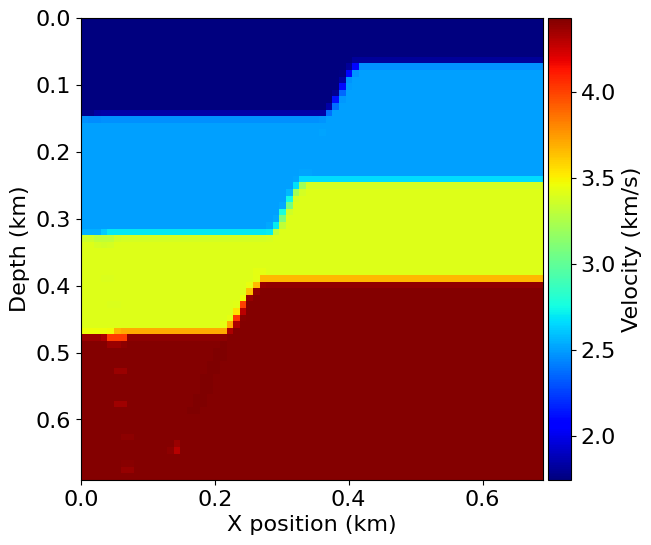

In [ ]:
#@title Parámetros del modelo sísmico

from examples.seismic import Model, plot_velocity

# ============================================================
# PARÁMETROS DE LA MALLA
# ============================================================

nx = 70  #@param {type:"integer", min:20, max:200, step:10}
nz = 70  #@param {type:"integer", min:20, max:200, step:10}

dx = 10.0  #@param {type:"number", min:1, max:50, step:1}
dz = 10.0  #@param {type:"number", min:1, max:50, step:1}

shape = (nx, nz)
spacing = (dx, dz)

# ============================================================
# PARÁMETROS DEL MÉTODO NUMÉRICO
# ============================================================

space_order = 2  #@param [2, 4, 6, 8]

nbl = 50  #@param {type:"integer", min:10, max:100, step:10}

# ============================================================
# CREACIÓN DEL MODELO
# ============================================================

origin = (0., 0.)

model = Model(
    vp=v.T,
    origin=origin,
    shape=shape,
    spacing=spacing,
    space_order=space_order,
    nbl=nbl,
    bcs="damp"
)

plot_velocity(model)

# Geometría de adquisición

Para definir completamente la configuración del problema, también es necesario establecer la **fuente sísmica**, encargada de introducir la onda en el modelo, y las posiciones de los **receptores**, donde se registrará el campo de ondas propagado.

La firma temporal de la fuente se modelará mediante una **wavelet de Ricker**, definida como:

$$
q(t)=
\left[
1-2\pi^{2}f_{0}^{2}
\left(t-\frac{1}{f_{0}}\right)^{2}
\right]
e^{
-\pi^{2}f_{0}^{2}
\left(t-\frac{1}{f_{0}}\right)^{2}
}
$$

donde $f_0$ corresponde a la **frecuencia pico de la fuente** y $t$ representa el tiempo.

Para definir completamente la señal de la fuente, primero se debe establecer la **duración de la simulación** y el **paso de tiempo**. Este último está condicionado por el criterio de estabilidad **CFL (Courant–Friedrichs–Lewy)** y por el espaciamiento de la malla.

La clase `Model` de Devito permite obtener automáticamente el paso de tiempo crítico mediante `model.critical_dt`. A partir de este valor se puede discretizar el eje temporal de la simulación.

> **Nota:** en esta práctica se consideran varias posiciones de fuente, pero cada una se simula como un **disparo independiente**. Por tanto, se utiliza una sola fuente activa (`npoint=1`) y su posición se actualiza para cada *shot*.


========== EJE TEMPORAL ==========
Tiempo inicial (t0):        0.0 ms
Tiempo final (tn):          1000.0 ms
Número de muestras (nt):    1000
Paso de tiempo usado (dt):  1.0010 ms
Critical dt (CFL máximo):   1.3820 ms

✅ Condición CFL satisfecha.
✅ La simulación tendrá exactamente 1000 muestras.

========== DISPAROS SÍSMICOS ==========
Número de disparos: 5
Frecuencia pico: 10.0 Hz
Profundidad: 5.0 m
Distribución: uniformemente espaciada

Posiciones de las fuentes:
Shot 1: x = 50.0 m, z = 5.0 m
Shot 2: x = 197.5 m, z = 5.0 m
Shot 3: x = 345.0 m, z = 5.0 m
Shot 4: x = 492.5 m, z = 5.0 m
Shot 5: x = 640.0 m, z = 5.0 m


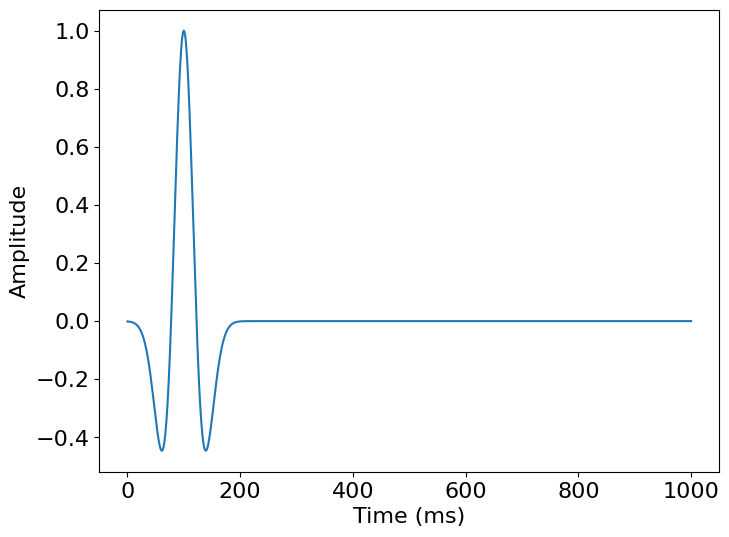

In [ ]:
#@title Parámetros de tiempo y fuentes sísmicas

from examples.seismic import TimeAxis, RickerSource
import numpy as np

# ============================================================
# EJE TEMPORAL
# ============================================================

# Tiempo inicial [ms]
t0 = 0.0  #@param {type:"number", min:0, max:1000, step:100}

# Tiempo final [ms]
# 1000 ms = 1 segundo
tn = 1000.0  #@param {type:"number", min:100, max:5000, step:100}

# Número de muestras temporales
# Se fija en 1000 para obtener el formato requerido por OpenFWI
nt = 1000

# ============================================================
# CREACIÓN DEL EJE TEMPORAL
# ============================================================

# Al indicar start, stop y num,
# Devito calcula automáticamente dt
time_range = TimeAxis(
    start=t0,
    stop=tn,
    num=nt
)

# Paso temporal realmente utilizado
dt = time_range.step

# Paso crítico permitido por CFL
critical_dt = model.critical_dt


# ============================================================
# VERIFICACIÓN DE ESTABILIDAD
# ============================================================

print("========== EJE TEMPORAL ==========")
print(f"Tiempo inicial (t0):        {t0:.1f} ms")
print(f"Tiempo final (tn):          {tn:.1f} ms")
print(f"Número de muestras (nt):    {time_range.num}")
print(f"Paso de tiempo usado (dt):  {dt:.4f} ms")
print(f"Critical dt (CFL máximo):   {critical_dt:.4f} ms")

# El paso utilizado debe ser menor o igual al crítico
if dt > critical_dt:
    raise ValueError(
        f"\n⚠️ El dt utilizado ({dt:.4f} ms) supera "
        f"el dt crítico ({critical_dt:.4f} ms).\n"
        "La simulación puede ser inestable.\n"
        "Aumente nt o disminuya tn."
    )

print("\n✅ Condición CFL satisfecha.")
print(f"✅ La simulación tendrá exactamente {time_range.num} muestras.")


# ============================================================
# PARÁMETROS DE LOS DISPAROS
# ============================================================

# Número de disparos independientes
nshots = 5  #@param {type:"integer", min:1, max:20, step:1}

# Frecuencia pico [kHz]
# 0.010 kHz = 10 Hz
f0 = 0.010  #@param {type:"number", min:0.005, max:0.050, step:0.005}

# Profundidad de las fuentes [m]
source_depth = 5.0  #@param {type:"number", min:1, max:100, step:1}

# Margen horizontal respecto a los bordes del modelo [m]
source_margin = 50.0  #@param {type:"number", min:0, max:200, step:10}


# ============================================================
# POSICIONES DE LOS DISPAROS
# ============================================================

# Verificar que el margen sea compatible con el tamaño del modelo
if 2 * source_margin >= float(model.domain_size[0]):
    raise ValueError(
        "source_margin es demasiado grande para el tamaño "
        "horizontal del modelo. Use un valor menor que la "
        "mitad de model.domain_size[0]."
    )


# Posiciones horizontales uniformemente espaciadas
shot_x = np.linspace(
    source_margin,
    float(model.domain_size[0]) - source_margin,
    nshots
)


# Matriz que contiene las coordenadas de todos los shots
#
# columna 0 -> posición X
# columna 1 -> profundidad Z

shot_coordinates = np.zeros(
    (nshots, 2),
    dtype=np.float32
)

shot_coordinates[:, 0] = shot_x
shot_coordinates[:, 1] = source_depth


# ============================================================
# CREACIÓN DE UNA ÚNICA FUENTE ACTIVA
# ============================================================

# Cada disparo se simula de manera independiente.
# Por esta razón solamente existe una fuente activa
# durante cada propagación.

src = RickerSource(
    name="src",
    grid=model.grid,
    f0=f0,
    npoint=1,
    time_range=time_range
)


# Inicialmente ubicar la fuente en el primer shot
src.coordinates.data[0, :] = shot_coordinates[0, :]


# ============================================================
# INFORMACIÓN DE LOS DISPAROS
# ============================================================

print("\n========== DISPAROS SÍSMICOS ==========")

print(f"Número de disparos: {nshots}")
print(f"Frecuencia pico: {f0*1000:.1f} Hz")
print(f"Profundidad: {source_depth:.1f} m")
print("Distribución: uniformemente espaciada")

print("\nPosiciones de las fuentes:")

for i in range(nshots):

    print(
        f"Shot {i+1}: "
        f"x = {shot_coordinates[i, 0]:.1f} m, "
        f"z = {shot_coordinates[i, 1]:.1f} m"
    )


# ============================================================
# VISUALIZACIÓN DE LA WAVELET
# ============================================================

src.show()

========== RECEPTORES ==========
Número de receptores: 70
Profundidad: 20.0 m
Distribución: uniforme a lo largo del eje x

Primer receptor:
[ 0. 20.]

Último receptor:
[690.  20.]


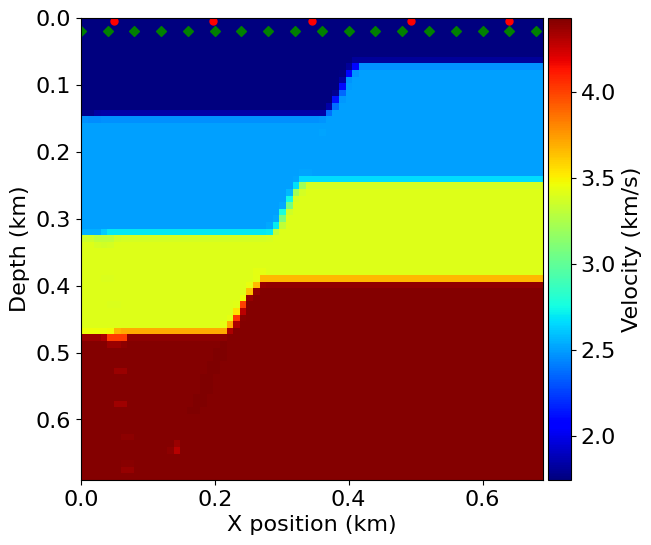

In [ ]:
#@title Geometría de los receptores

from examples.seismic import Receiver
from examples.seismic import plot_velocity
import numpy as np

# ============================================================
# PARÁMETROS DE LOS RECEPTORES
# ============================================================

# Número de receptores
nreceivers = 70  #@param {type:"integer", min:10, max:300, step:1}

# Profundidad de los receptores [m]
receiver_depth = 20.0  #@param {type:"number", min:0, max:100, step:5}


# ============================================================
# CREACIÓN DE LOS RECEPTORES
# ============================================================

rec = Receiver(
    name="rec",
    grid=model.grid,
    npoint=nreceivers,
    time_range=time_range
)


# ============================================================
# POSICIÓN DE LOS RECEPTORES
# ============================================================

# Distribución uniforme de los receptores a lo largo del eje x
rec.coordinates.data[:, 0] = np.linspace(
    0,
    model.domain_size[0],
    num=nreceivers
)

# Profundidad constante de los receptores
rec.coordinates.data[:, 1] = receiver_depth


# ============================================================
# INFORMACIÓN DE LA GEOMETRÍA
# ============================================================

print("========== RECEPTORES ==========")
print(f"Número de receptores: {nreceivers}")
print(f"Profundidad: {receiver_depth} m")
print("Distribución: uniforme a lo largo del eje x")

print("\nPrimer receptor:")
print(rec.coordinates.data[0, :])

print("\nÚltimo receptor:")
print(rec.coordinates.data[-1, :])


# ============================================================
# VISUALIZACIÓN DE LA GEOMETRÍA DE ADQUISICIÓN
# ============================================================

# Se muestran todas las posiciones posibles de disparo,
# aunque cada una se simulará de forma independiente.
plot_velocity(
    model,
    source=shot_coordinates,
    receiver=rec.coordinates.data[::4, :]
)


# Discretización por diferencias finitas

Devito es un lenguaje específico de dominio (DSL) basado en **diferencias finitas**, diseñado para resolver numéricamente la ecuación de onda discretizada sobre una malla cartesiana.

---

## Discretización temporal

En este caso consideraremos una **discretización temporal de segundo orden**.

A partir de la expansión de Taylor, la segunda derivada temporal del campo de onda puede aproximarse mediante:

$$
\frac{\partial^2 u(\mathbf{x},t)}{\partial t^2}
=
\frac{
u(\mathbf{x},t+\Delta t)
-2u(\mathbf{x},t)
+u(\mathbf{x},t-\Delta t)
}{
\Delta t^2
}
+
\mathcal{O}(\Delta t^2)
$$

donde:

- $u(\mathbf{x},t)$ representa el **campo de onda** en la posición $\mathbf{x}$ y en el instante $t$.
- $\Delta t$ corresponde al **paso de tiempo** entre dos instantes consecutivos de la simulación.
- $u(\mathbf{x},t+\Delta t)$ representa el campo de onda en el siguiente instante de tiempo.
- $u(\mathbf{x},t-\Delta t)$ representa el campo de onda en el instante anterior.
- $\mathcal{O}(\Delta t^2)$ representa el **error de truncamiento** asociado a una aproximación temporal de segundo orden.

Al despreciar el término de error, obtenemos:

$$
\boxed{
\frac{\partial^2 u}{\partial t^2}
\approx
\frac{
u^{n+1}-2u^n+u^{n-1}
}{
\Delta t^2
}
}
$$

Esta expresión muestra que para calcular el campo de onda en un instante determinado se utilizan valores correspondientes al **tiempo actual, al tiempo anterior y al tiempo siguiente**.

En Devito, esta segunda derivada temporal se representa simbólicamente mediante:

```python
u.dt2

In [ ]:
#@title Definición del campo de onda y la PDE

from devito import TimeFunction
from IPython.display import display

# ============================================================
# CAMPO DE ONDA
# ============================================================

# Orden temporal de la discretización
time_order = 2  #@param [2, 4]

# Crear el campo de onda u(x,z,t)
u = TimeFunction(
    name="u",
    grid=model.grid,
    time_order=time_order,
    space_order=space_order
)

# ============================================================
# ECUACIÓN DIFERENCIAL PARCIAL
# ============================================================

# Ecuación de onda acústica con amortiguamiento:
#
#       m*u_tt - ∇²u + damp*u_t = 0
#
# donde:
# m     -> cuadrado de la lentitud (1/v²)
# u_tt  -> segunda derivada temporal
# ∇²u   -> Laplaciano espacial
# damp  -> término de amortiguamiento

pde = model.m * u.dt2 - u.laplace + model.damp * u.dt

# ============================================================
# INFORMACIÓN
# ============================================================

print("========== CAMPO DE ONDA ==========")
print(f"Orden temporal: {time_order}")
print(f"Orden espacial: {space_order}")

print("\n========== PDE ==========")

display(pde)

========== CAMPO DE ONDA ==========
Orden temporal: 2
Orden espacial: 2

========== PDE ==========


damp(x, y)*Derivative(u(t, x, y), t) - Derivative(u(t, x, y), (x, 2)) - Derivative(u(t, x, y), (y, 2)) + Derivative(u(t, x, y), (t, 2))/vp(x, y)**2

## Esquema de actualización temporal

Una vez definida la ecuación diferencial parcial discretizada, podemos resolverla de forma iterativa en el tiempo.

La idea consiste en calcular el campo de onda en el siguiente instante,

$$
u(\mathbf{x},t+\Delta t),
$$

a partir de los valores conocidos del campo de onda en los instantes anteriores.

En Devito, el campo de onda correspondiente al siguiente paso temporal se representa mediante:

$$
u(\mathbf{x},t+\Delta t)
\quad \longrightarrow \quad
\texttt{u.forward}
$$

Para una discretización temporal de segundo orden, la propagación sigue conceptualmente el esquema:

$$
u^{n+1}
\leftarrow
F\left(
u^n,
u^{n-1},
\nabla^2u^n,
m,
\text{damp}
\right),
$$

donde:

- $u^{n+1}$ representa el campo de onda en el siguiente instante.
- $u^n$ representa el campo de onda en el instante actual.
- $u^{n-1}$ representa el campo de onda en el instante anterior.
- $\nabla^2u$ contiene la contribución de las derivadas espaciales.
- $m$ contiene las propiedades del medio.
- `damp` representa la capa de amortiguamiento utilizada para reducir reflexiones en los bordes.

Devito permite despejar simbólicamente `u.forward` utilizando la función `solve`.  
El resultado se denomina **stencil**, es decir, la regla numérica que se aplicará repetidamente para avanzar la solución en el tiempo.

In [ ]:
#@title Construcción del esquema de actualización (stencil)

from devito import Eq, solve
from IPython.display import display

# ============================================================
# DESPEJAR EL CAMPO DE ONDA EN EL SIGUIENTE PASO DE TIEMPO
# ============================================================

# u.forward representa:
#
#             u(x, t + dt)
#
# solve() despeja u.forward de la PDE
# Eq() construye la ecuación simbólica de actualización

stencil = Eq(
    u.forward,
    solve(pde, u.forward)
)


# ============================================================
# MOSTRAR EL STENCIL
# ============================================================

print("========== STENCIL DE PROPAGACIÓN ==========")
print("Campo a actualizar: u(x, t + dt)")
print()

display(stencil)

========== STENCIL DE PROPAGACIÓN ==========
Campo a actualizar: u(x, t + dt)



Eq(u(t + dt, x, y), (-(-2.0*u(t, x, y)/dt**2 + u(t - dt, x, y)/dt**2)/vp(x, y)**2 + Derivative(u(t, x, y), (x, 2)) + Derivative(u(t, x, y), (y, 2)) + damp(x, y)*u(t, x, y)/dt)/(damp(x, y)/dt + 1/(dt**2*vp(x, y)**2)))

## Inyección de la fuente y registro en los receptores

Una vez construido el esquema de actualización temporal (*stencil*), debemos incorporar la **fuente sísmica** dentro de la ecuación de propagación y definir cómo se registrará el campo de onda en las posiciones de los receptores.

### Inyección de la fuente

La wavelet de Ricker definida anteriormente representa la señal temporal emitida por la fuente. Durante cada paso de tiempo, esta señal debe introducirse en el campo de onda.

En Devito, la inyección de la fuente se realiza mediante:

```python
src.inject(...)

In [ ]:
#@title Inyección de la fuente y registro en receptores

# Inyección de UNA fuente
src_term = src.inject(
    field=u.forward,
    expr=src * dt**2 / model.m
)

# Registro en los receptores
rec_term = rec.interpolate(
    expr=u.forward
)

print("Término de fuente creado.")
print("Término de receptores creado.")

Término de fuente creado.
Término de receptores creado.


In [ ]:
#@title Construcción del operador de propagación

from devito import Operator

op = Operator(
    [stencil] + src_term + rec_term,
    subs=model.spacing_map
)

print("Operador construido correctamente.")

Operador construido correctamente.


In [ ]:
#@title Simulación de los disparos independientes

# ============================================================
# ARREGLO PARA GUARDAR TODOS LOS SHOT GATHERS
# ============================================================

shot_records = np.zeros(
    (
        nshots,
        time_range.num,
        nreceivers
    ),
    dtype=np.float32
)


# ============================================================
# LOOP SOBRE LOS DISPAROS
# ============================================================

for ishot in range(nshots):

    print(
        f"\nSimulando shot {ishot+1}/{nshots} "
        f"en x = {shot_x[ishot]:.1f} m"
    )

    # --------------------------------------------------------
    # 1. MOVER LA FUENTE A LA POSICIÓN DEL SHOT ACTUAL
    # --------------------------------------------------------

    src.coordinates.data[0, 0] = shot_x[ishot]
    src.coordinates.data[0, -1] = source_depth


    # --------------------------------------------------------
    # 2. REINICIAR EL CAMPO DE ONDA
    # --------------------------------------------------------

    u.data[:] = 0.0


    # --------------------------------------------------------
    # 3. REINICIAR LOS DATOS DE LOS RECEPTORES
    # --------------------------------------------------------

    rec.data[:] = 0.0


    # --------------------------------------------------------
    # 4. EJECUTAR LA PROPAGACIÓN
    # --------------------------------------------------------

    op(
        time=time_range.num - 1,
        dt=dt
    )


    # --------------------------------------------------------
    # 5. GUARDAR EL SHOT GATHER
    # --------------------------------------------------------

    shot_records[ishot, :, :] = rec.data[:]


print("\n==========================================")
print("SIMULACIÓN FINALIZADA")
print("==========================================")
print(f"Número de shots: {nshots}")
print(f"Número de pasos temporales: {time_range.num}")
print(f"Número de receptores: {nreceivers}")

print("\nDimensiones de shot_records:")
print(shot_records.shape)

print("\nFormato:")
print("(shot, tiempo, receptor)")



Simulando shot 1/5 en x = 50.0 m

Simulando shot 2/5 en x = 197.5 m

Simulando shot 3/5 en x = 345.0 m

Simulando shot 4/5 en x = 492.5 m

Simulando shot 5/5 en x = 640.0 m

SIMULACIÓN FINALIZADA
Número de shots: 5
Número de pasos temporales: 1000
Número de receptores: 70

Dimensiones de shot_records:
(5, 1000, 70)

Formato:
(shot, tiempo, receptor)


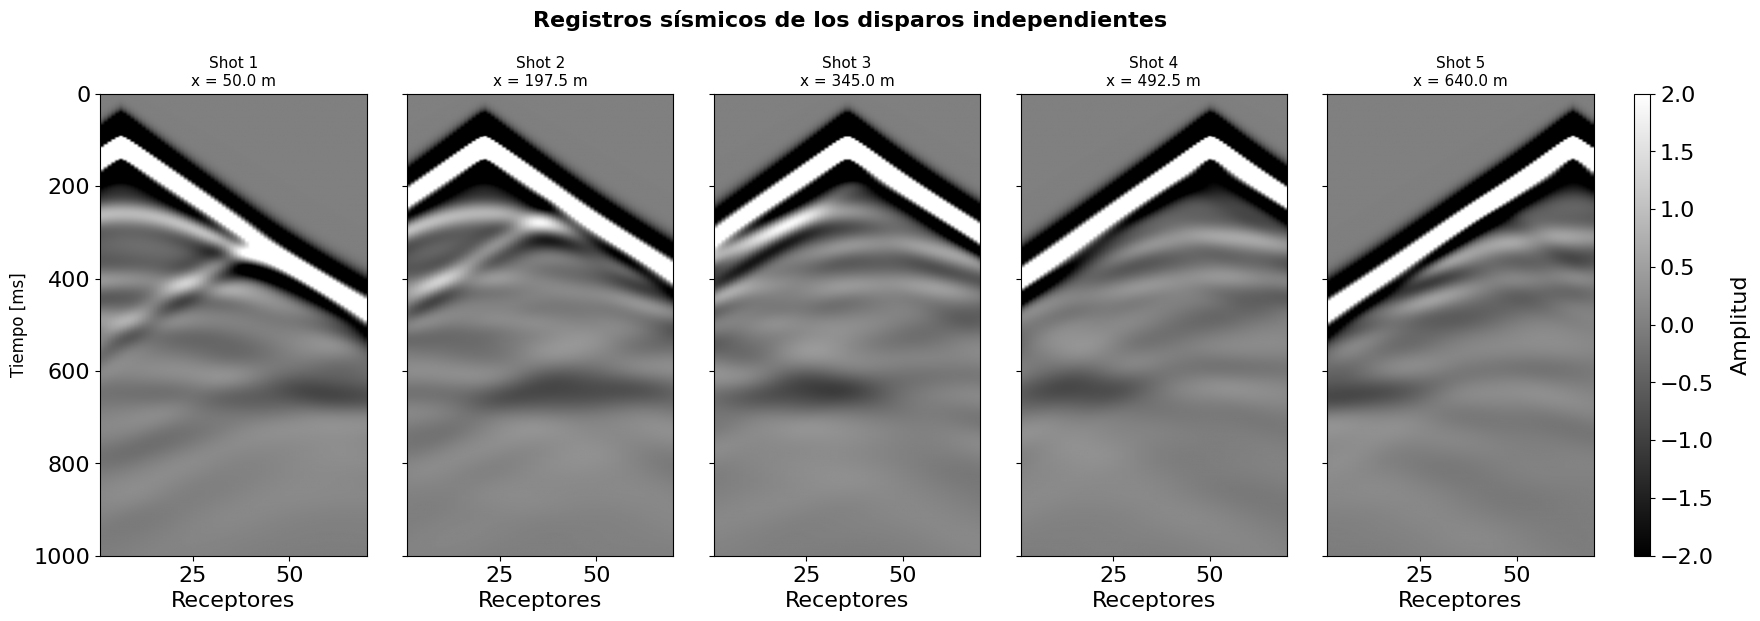

In [ ]:
#@title Visualización conjunta de todos los shot gathers

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# ESCALA DE AMPLITUD
# ============================================================

# Límites de amplitud para ajustar el contraste de la imagen
vmin = -2.0  #@param {type:"number", min:-20, max:0, step:0.5}
vmax = 2.0   #@param {type:"number", min:0, max:20, step:0.5}

# Verificación
if vmin >= vmax:
    raise ValueError("vmin debe ser menor que vmax.")


# ============================================================
# CREAR FIGURA CON ESPACIO EXCLUSIVO PARA EL COLORBAR
# ============================================================

fig = plt.figure(figsize=(20, 6))

# 5 paneles + columna exclusiva para el colorbar
gs = fig.add_gridspec(
    1,
    nshots + 1,
    width_ratios=[1] * nshots + [0.06],
    wspace=0.18
)

axes = []


# ============================================================
# GRAFICAR CADA SHOT
# ============================================================

for ishot in range(nshots):

    if ishot == 0:

        ax = fig.add_subplot(gs[0, ishot])

    else:

        ax = fig.add_subplot(
            gs[0, ishot],
            sharey=axes[0]
        )

    axes.append(ax)

    im = ax.imshow(
        shot_records[ishot, :, :],
        cmap="gray",
        aspect="auto",
        vmin=vmin,
        vmax=vmax,
        extent=[
            1,
            nreceivers,
            tn,
            t0
        ]
    )

    ax.set_title(
        f"Shot {ishot+1}\n"
        f"x = {shot_x[ishot]:.1f} m",
        fontsize=11
    )

    ax.set_xlabel("Receptores")

    # Mostrar los valores del tiempo solo en el primer panel
    if ishot != 0:
        ax.tick_params(
            axis="y",
            labelleft=False
        )


# ============================================================
# EJE TEMPORAL
# ============================================================

axes[0].set_ylabel(
    "Tiempo [ms]",
    fontsize=12
)


# ============================================================
# COLORBAR
# ============================================================

cax = fig.add_subplot(gs[0, -1])

cbar = fig.colorbar(
    im,
    cax=cax
)

cbar.set_label(
    "Amplitud",
    rotation=90,
    labelpad=12
)


# ============================================================
# TÍTULO GENERAL
# ============================================================

fig.suptitle(
    "Registros sísmicos de los disparos independientes",
    fontsize=16,
    fontweight="bold",
    y=1.02
)


plt.show()

In [ ]:
#@title Exportar modelo de velocidad y datos sísmicos

import os
import numpy as np

# ============================================================
# CARPETA DE SALIDA
# ============================================================

# Carpeta principal creada anteriormente
OUTPUT_ROOT = "/content/drive/MyDrive/OpenFWI_resultados"

# Crear subcarpeta Data
DATA_DIR = os.path.join(OUTPUT_ROOT, "Data")
os.makedirs(DATA_DIR, exist_ok=True)
# ============================================================
# NOMBRE DEL EJEMPLO
# ============================================================

sample_name = "FlatVel"  #@param {type:"string"}


# ============================================================
# 1. MODELO DE VELOCIDAD
# ============================================================

# 'vel' corresponde al modelo original cargado desde el .npy
# Antes de dividir la velocidad por 1000 para trabajar con Devito.

velocity_2d = np.squeeze(vel).astype(np.float32)

# Verificar dimensiones
if velocity_2d.shape != (70, 70):
    raise ValueError(
        f"El modelo de velocidad debería tener shape (70, 70), "
        f"pero tiene {velocity_2d.shape}"
    )

# Agregar:
# dimensión de muestra
# dimensión de canal
#
# (70,70) --> (1,1,70,70)

velocity_export = velocity_2d[
    np.newaxis,
    np.newaxis,
    :,
    :
]


# ============================================================
# 2. DATOS SÍSMICOS
# ============================================================

# Actualmente:
#
# shot_records.shape =
# (5, 714, 70)
#
# Queremos:
#
# (1, 5, 1000, 70)

nshots_export = 5
nt_export = 1000
nreceivers_export = 70


# Verificaciones
if shot_records.shape[0] != nshots_export:
    raise ValueError(
        f"Se esperaban {nshots_export} shots, "
        f"pero hay {shot_records.shape[0]}"
    )

if shot_records.shape[2] != nreceivers_export:
    raise ValueError(
        f"Se esperaban {nreceivers_export} receptores, "
        f"pero hay {shot_records.shape[2]}"
    )


# ============================================================
# INTERPOLACIÓN TEMPORAL
# ============================================================

nt_original = shot_records.shape[1]

# Eje temporal normalizado original
t_original = np.linspace(
    0.0,
    1.0,
    nt_original
)

# Nuevo eje con exactamente 1000 muestras
t_new = np.linspace(
    0.0,
    1.0,
    nt_export
)

# Crear arreglo destino
shot_1000 = np.zeros(
    (
        nshots_export,
        nt_export,
        nreceivers_export
    ),
    dtype=np.float32
)


# Interpolar cada traza sísmica
for ishot in range(nshots_export):

    for irec in range(nreceivers_export):

        shot_1000[ishot, :, irec] = np.interp(
            t_new,
            t_original,
            shot_records[ishot, :, irec]
        )


# Agregar dimensión correspondiente a la muestra
#
# (5,1000,70)
#       ↓
# (1,5,1000,70)

seismic_export = shot_1000[np.newaxis, :, :, :]


# ============================================================
# 3. GUARDAR ARCHIVOS
# ============================================================

velocity_path = os.path.join(
    DATA_DIR,
    f"{sample_name}_velocity.npy"
)

seismic_path = os.path.join(
    DATA_DIR,
    f"{sample_name}_seismic.npy"
)

np.save(
    velocity_path,
    velocity_export
)

np.save(
    seismic_path,
    seismic_export
)


# ============================================================
# 4. VERIFICAR ARCHIVOS GUARDADOS
# ============================================================

velocity_check = np.load(velocity_path)
seismic_check = np.load(seismic_path)

assert velocity_check.shape == (1, 1, 70, 70)
assert seismic_check.shape == (1, 5, 1000, 70)


# ============================================================
# RESULTADO
# ============================================================

print("\n==========================================")
print("✅ DATOS EXPORTADOS CORRECTAMENTE")
print("==========================================")

print("\n📁 Carpeta:")
print(DATA_DIR)

print("\n🌍 Modelo de velocidad:")
print(velocity_path)
print("Shape:", velocity_check.shape)

print("\n📡 Datos sísmicos:")
print(seismic_path)
print("Shape:", seismic_check.shape)

print("\n✅ Formato final compatible:")
print("Velocity :", velocity_check.shape)
print("Seismic  :", seismic_check.shape)


✅ DATOS EXPORTADOS CORRECTAMENTE

📁 Carpeta:
/content/drive/MyDrive/OpenFWI_resultados/Data

🌍 Modelo de velocidad:
/content/drive/MyDrive/OpenFWI_resultados/Data/FlatVel_velocity.npy
Shape: (1, 1, 70, 70)

📡 Datos sísmicos:
/content/drive/MyDrive/OpenFWI_resultados/Data/FlatVel_seismic.npy
Shape: (1, 5, 1000, 70)

✅ Formato final compatible:
Velocity : (1, 1, 70, 70)
Seismic  : (1, 5, 1000, 70)
